# MODELADO HÍBRIDO DE LA SEVERIDAD

En este notebook el objetivo será la predicción pura y supervisada de la siniestralidad total recogida en nuestra variable objetivo `Total Claim Amount`. Decimos que vamos a realizar un modelado fundamentado en dos grandes metodologías:
1. **Modelo Lineal Generalizado y EVT**. Nos permitirán modelar la severidad de la cartera de clientes. Será un modelo base contra el cual contrastar el modelo obtenido por el uso de la siguiente metodología.
2. **Red Neuronal Bayesiana**. La segmentación de los perfiles de riesgo nos permitirá aplicar esta técnica, la cual nos dirá no solo la severidad predicha, también nos permitirá conocer cual es la incertidumbre epistémica, si un dato es muy anómalo sabremos que la estimación es incierta.

##### Setup del Notebook

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import kruskal, anderson, kstest, gamma, lognorm, weibull_min, genpareto, probplot

# ── Reproducibilidad ──
SEED = 42
np.random.seed(SEED)

# ── Paths ──
PH2_PATH = '../data/processed/fase2/v2/'
DATA_PATH  = '../data/processed/fase3/v2/'
OUTPUT_DIR = '../data/processed/fase4/'   # donde se guardan los artefactos para las fases siguientes

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

##### Carga de Datos

In [14]:
df_og = pd.read_excel(DATA_PATH + "vbles_og_cluster.xlsx")
print(f"Dataset cargado: {df_og.shape[0]:,} registros × {df_og.shape[1]} variables")
columnas = df_og.columns.to_list()
print(f"Las columnas del conjunto de datos son:\n{columnas}")

Dataset cargado: 8,971 registros × 26 variables
Las columnas del conjunto de datos son:
['Customer', 'FC1', 'FC2', 'FC3', 'FC4', 'FC5', 'Total Claim Amount', 'State', 'Customer Lifetime Value', 'Coverage', 'Education', 'EmploymentStatus', 'Gender', 'Income', 'Location Code', 'Marital Status', 'Monthly Premium Auto', 'Months Since Last Claim', 'Months Since Policy Inception', 'Number of Open Complaints', 'Number of Policies', 'Policy Type', 'Vehicle Class', 'Vehicle Size', 'Cluster_Final', 'Atipicidad']


## 1.- MODELADO DE LA CARTERA
Como hemos dicho lo primero que debemos hacer es obtener un modelo que nos permita obtener predicciones sobre la severidad de los clientes. Para ello, lo habitual en la industria aseguradora es el udso de GLM gracias a su alta interpretabilidad. En la fase 1 de Exploración y Limpieza de Datos hicimos algunas indagaciones sobre que distibución se ajustaba mejor a nuestra variable objetivo:

--- Ajuste de distribuciones de severidad (Kolmogorov-Smirnov) ---
  Gamma:     KS = 0.1246 | p-valor = 0.0000
  Lognormal: KS = 0.1799 | p-valor = 0.0000
  Weibull:   KS = 0.1047 | p-valor = 0.0000


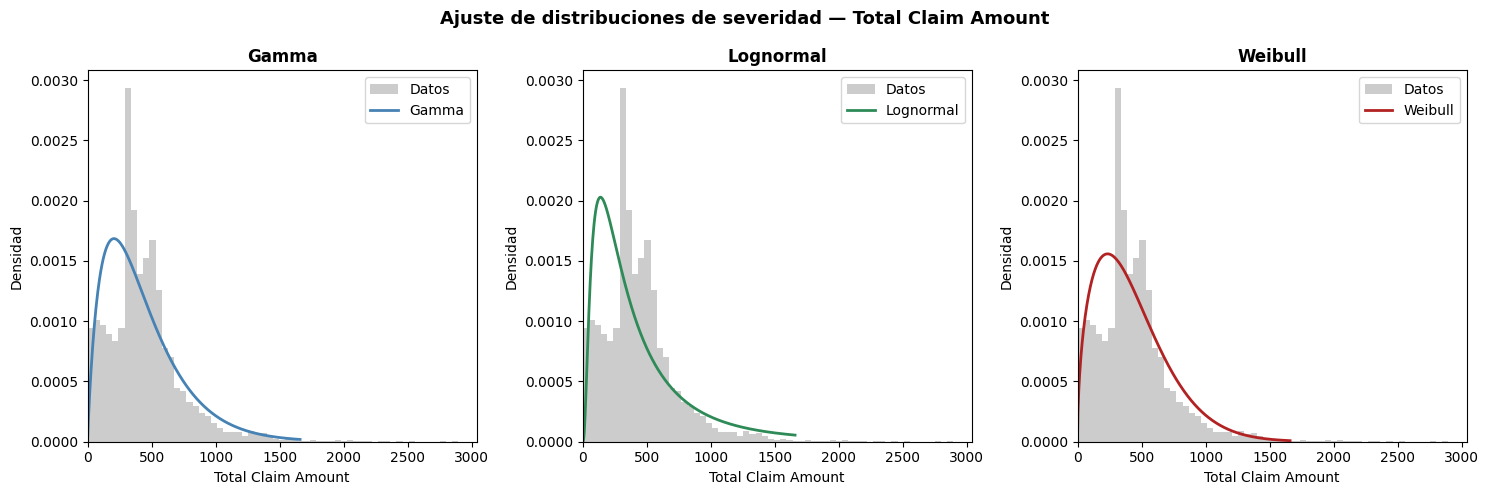

In [15]:
# --- Extracción de la Variable Objetivo --- 
y_target = df_og[['Customer', 'Total Claim Amount']].copy()
y_values = y_target['Total Claim Amount'].values

# --- Ajuste de Distibuciones --- #
gfit  = gamma.fit(y_values, floc=0)
lfit  = lognorm.fit(y_values, floc=0)
wfit  = weibull_min.fit(y_values, floc=0)

ks_g, p_g = kstest(y_values, 'gamma',      args=gfit)
ks_l, p_l = kstest(y_values, 'lognorm',    args=lfit)
ks_w, p_w = kstest(y_values, 'weibull_min', args=wfit)

print("--- Ajuste de distribuciones de severidad (Kolmogorov-Smirnov) ---")
print(f"  Gamma:     KS = {ks_g:.4f} | p-valor = {p_g:.4f}")
print(f"  Lognormal: KS = {ks_l:.4f} | p-valor = {p_l:.4f}")
print(f"  Weibull:   KS = {ks_w:.4f} | p-valor = {p_w:.4f}")

# --- Visualización ---
x = np.linspace(y_values.min(), np.percentile(y_values, 99.5), 500)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

dist_configs = [
    ('Gamma',    gamma,       gfit,  'steelblue'),
    ('Lognormal', lognorm,    lfit,  'seagreen'),
    ('Weibull',  weibull_min, wfit,  'firebrick'),
]

for ax, (name, dist_obj, fit_params, color) in zip(axes, dist_configs):
    ax.hist(y_values, bins=60, density=True, alpha=0.4, color='grey', label='Datos')
    ax.plot(x, dist_obj.pdf(x, *fit_params), color=color, lw=2, label=name)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Total Claim Amount')
    ax.set_ylabel('Densidad')
    ax.legend()
    ax.set_xlim(left=0)

plt.suptitle('Ajuste de distribuciones de severidad — Total Claim Amount',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

De acuerdo al Test de Kolgomorov-Smirnov la Weibull y la Gamma son las principales candidatas para este ajuste, al tener el menor valor para el estadístico KS. Sin embargo, el p-valor de las tres distribuciones rechaza la hipótesis nula de que `Total Claim Amount` siga cualquiera de estas distribuciones. Si visualizamos los QQ-plot obtenemos una perspectiva muy clara de por que puede estar ocurriendo esto.

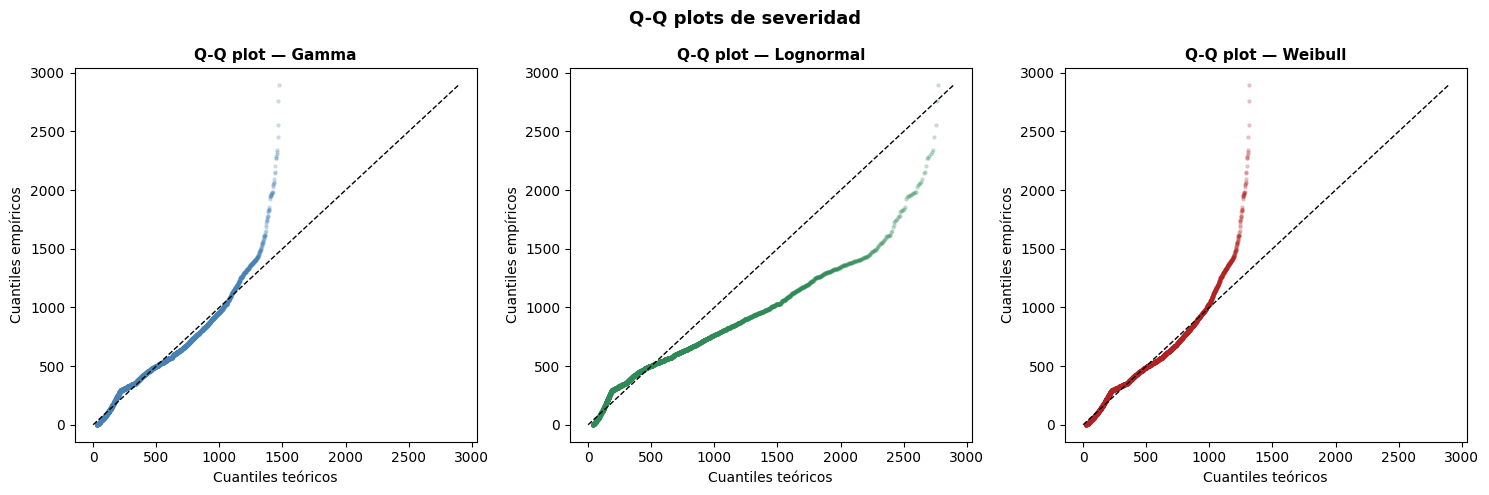

In [16]:
# --- Q-Q plots para las tres distribuciones ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, dist_obj, fit_params, color) in zip(axes, dist_configs):
    theoretical_q = dist_obj.ppf(np.linspace(0.01, 0.99, len(y_values)), *fit_params)
    empirical_q   = np.sort(y_values)
    ax.scatter(theoretical_q, empirical_q, alpha=0.2, s=5, color=color)
    lim = max(theoretical_q.max(), empirical_q.max())
    ax.plot([0, lim], [0, lim], 'k--', lw=1)
    ax.set_title(f'Q-Q plot — {name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Cuantiles teóricos')
    ax.set_ylabel('Cuantiles empíricos')

plt.suptitle('Q-Q plots de severidad', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Estos QQ-plots son reveladores y nos muestran como las distribuciones propuestas, en especial la Weibull y la Gamma se adaptan bien al cuerpo de la muestra de la variable objetivo; sin embargo, las dos caen en una subestimación del riesgo de cola. Es por ello que creemos conveniente usar la Teoría de Valores Extremos y modelar de manera independiente el cuerpo de la distibución, donde se producen la mayoría de los siniestros con una severidad media y por otro lado la cola, donde los siniestros son escasos pero muy costosos.

El primer paso que debemos dar para llevar a cabo esta modelización es determinar el umbral que define el punto exacto donde termina el cuerpo de la distribución y comienza la cola. Para ello usaremos dos herramientas estadísticas que nos ayudarán a encontrar este umbral:
1. _Mean Excess Plot_. Este gráfico respresenta el exceso medio, debemos buscar el punto a partir del cual el exceso esperado sobre el umbral es lineal.
2. _Hill Plot_. Nos permitira analizar la estabilidad del índice de cola

##### Mean Excess Plot

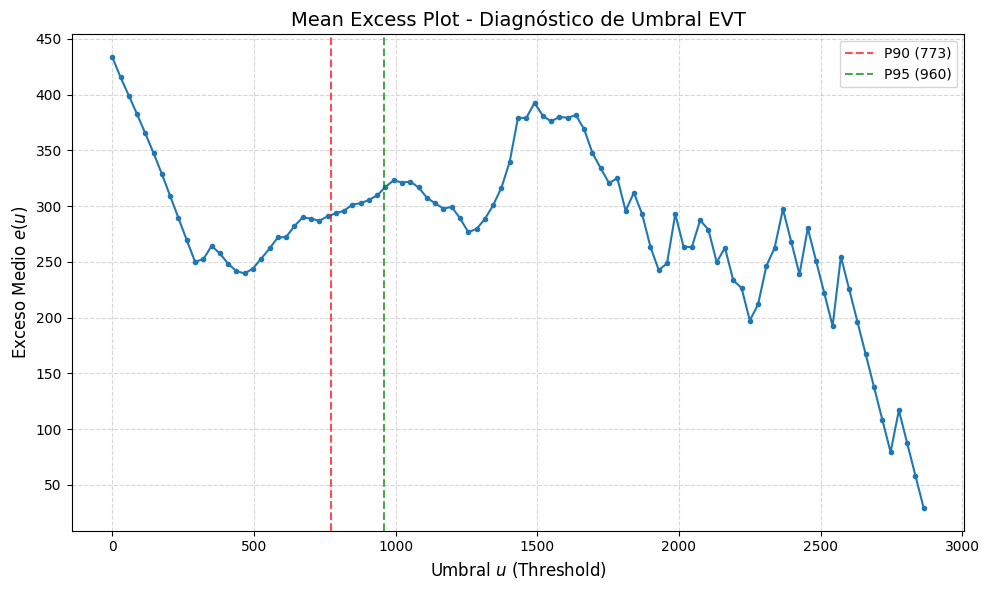

In [17]:
# 2. Definir rango de umbrales a evaluar (desde la mediana hasta el percentil 99)
u_min = np.percentile(y_values, 0)
u_max = np.percentile(y_values, 100)
thresholds = np.linspace(u_min, u_max, 100)

mean_excess = []

# 3. Calcular el exceso medio para cada umbral
for u in thresholds:
    # Seleccionamos los siniestros que superan el umbral u
    excesses = y_values[y_values > u] - u
    # Calculamos la media de estos excesos
    mean_excess.append(np.mean(excesses) if len(excesses) > 0 else np.nan)

# 4. Visualización Diagnóstica
plt.figure(figsize=(10, 6))
plt.plot(thresholds, mean_excess, marker='.', linestyle='-', color='#1f77b4')

# Líneas de referencia para cuantiles típicos en Seguros
p90 = np.percentile(y_values, 90)
p95 = np.percentile(y_values, 95)

plt.axvline(x=p90, color='red', linestyle='--', alpha=0.7, label=f'P90 ({p90:.0f})')
plt.axvline(x=p95, color='green', linestyle='--', alpha=0.7, label=f'P95 ({p95:.0f})')

plt.title('Mean Excess Plot - Diagnóstico de Umbral EVT', fontsize=14)
plt.xlabel('Umbral $u$ (Threshold)', fontsize=12)
plt.ylabel('Exceso Medio $e(u)$', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Atendiendo a este gráfico distinguimos varias zonas claramente diferenciadas:
1. Zona de caida hasta $u \approx 300$, asociada al cuerpo de la distribución.
2. Oscilaciones y estabilidad hasta $u \approx 700$, esto se asocia hasta una zona de transición.
3. Ascenso lineal en $u \in (500,1000)$ esto quiere decir que probablemente encontremos aquí nuestro umbral de cola. Si nos fijamos en el gráfico, el ascenso lineal se hace más o menos constante a partir del percentil 90 marcado en rojo. El percentil 95 está más cerca de oscilaciones que se suelen asociar con ruido estadístico.
4. Caida errática con oscilaciones violentas a partir de $u \approx 1600$ asociada a muy pocos datos.

Tomamos como dos buenos candidatos parar fija el umbral de cola el percentil 90% y el percentil 95%. Posteriormente validaremos cual de estos nos permite un mejor ajuste de los modelos GLM para el cuerpo y Pareto Generalizada (GDP) para la cola.

| Percentil | Valor | Tamaño del cuerpo | Tamaño de la Cola |
| --- | --- | --- | --- |
| **90%** | 773 | 8074 | 897 |
| **95%** | 960 | 8522 | 449 |

##### Hill Plot
Este gráfico nos ayuda a encontrar la estabilidad del parámetro de cola $\xi$, (si $\xi > 0$ nos econtramos ante una distribución de cola pesada). En el eje X se representan el número de siniestros que estamos considerando, de forma que si X = 900, estamos considerando los 900 siniestros más caros. En el eje Y encontramos el valor estimado del indice de cola ($\hat{\xi}$), buscamos una zona donde este valor se mantenga relativamente constante.

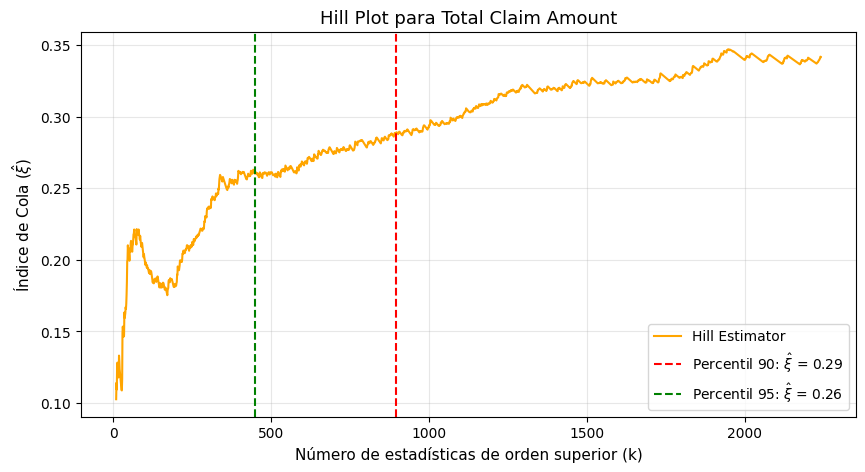

In [18]:
y_values_ord = np.sort(y_values)[::-1]
n = len(y_values_ord)

k_max = n // 4  # Evaluamos hasta el percentil 75%

k_values = np.arange(10, k_max)
hill_estimates = []

# 2. Cálculo del estimador de Hill para cada k
for k in k_values:
    # Hill formula: average of log(X_i / X_{k+1})
    top_k = y_values_ord[:k]
    log_diffs = np.log(top_k / y_values_ord[k])
    hill_estimates.append(np.mean(log_diffs))

# 3. Visualización
plt.figure(figsize=(10, 5))
plt.plot(k_values, hill_estimates, color='orange', label='Hill Estimator')
plt.axvline(x=897, color='red', linestyle='--', label=f'Percentil 90: $\hat{{\\xi}}$ = {hill_estimates[898]:.2f}')
plt.axvline(x=449, color='green', linestyle='--', label=f'Percentil 95: $\hat{{\\xi}}$ = {hill_estimates[450]:.2f}')

plt.title('Hill Plot para Total Claim Amount', fontsize=13)
plt.xlabel('Número de estadísticas de orden superior (k)', fontsize=11)
plt.ylabel('Índice de Cola ($\hat{\\xi}$)', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

La meseta estable comienza en $X \approx 300$ y se mantiene hasta $X \approx 900$. Los valores inferiores a 300 tienen un ascenso inestable con oscilaciones bruscas asociadas a la falta de datos. Los valores de $X \in (900,2000)$ mantienen una deriva lenta ascendente y los valores superiores a 2000 empiezan a oscilar por la contaminación del cuerpo de la muestra. En este caso el percentil 95 asociado a los 449 clientes con mayor severidad es el mejor candidato, y el percentil 90 con 897 clientes es un buen dato pero ya queda en el final de la meseta. Para tomar una decisión sobre donde situar la cola de nuestra distribución veremos métricas sobre cual permite un mejor ajuste tanto en cola como en el cuerpo.

### 1.1 Ajuste del cuerpo

Comprobamos cual de las dos distribuciones (_Weibull_ o _Gamma_) ajusta mejor el cuerpo de nuestra muestra, aprovechamos para validar también si lo hacen mejor sobre un cuerpo del 90 % o del 95% de las observaciones


# --- BONDAD DE AJUSTE (Estadístico KS) --- #
Distribución  Cuerpo P90  Cuerpo P95
       Gamma    0.048278    0.060559
     Weibull    0.058014    0.069837


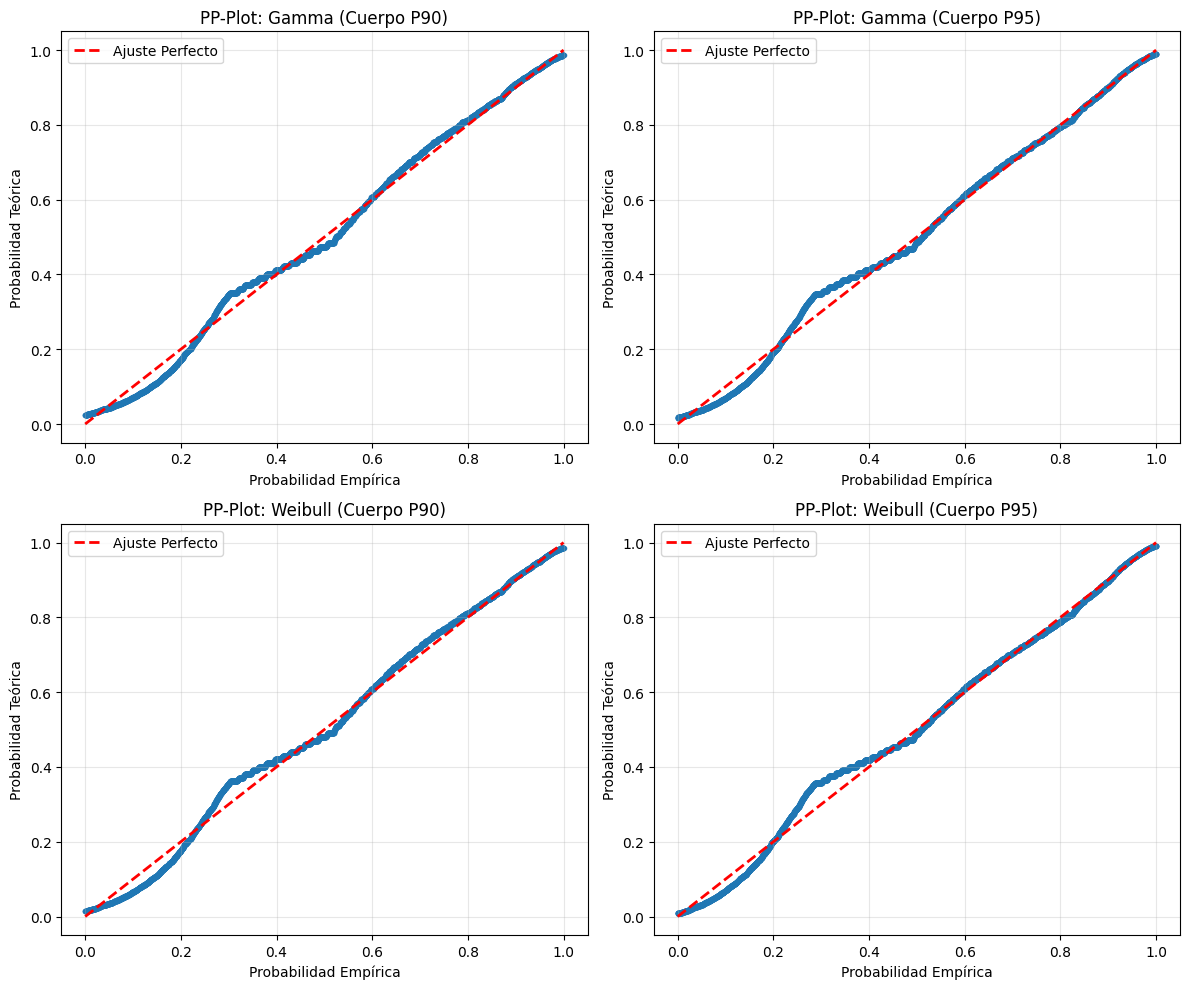

In [19]:
p90 = np.percentile(y_values, 90)
p95 = np.percentile(y_values, 95)

body90 = y_values[y_values <= p90]
body95 = y_values[y_values <= p95]

# 3. Función para graficar PP-Plots modulares
def plot_pp(ax, data, dist, params, title):
    n = len(data)
    y = np.sort(data)
    empirical_p = np.arange(1, n + 1) / n
    theoretical_p = dist.cdf(y, *params)
    
    ax.scatter(empirical_p, theoretical_p, marker='.', alpha=0.5, color='#1f77b4')
    ax.plot([0, 1], [0, 1], 'r--', lw=2, label='Ajuste Perfecto')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Probabilidad Empírica')
    ax.set_ylabel('Probabilidad Teórica')
    ax.legend()
    ax.grid(True, alpha=0.3)

# 4. Evaluación de los Modelos
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
distributions = [('Gamma', gamma), ('Weibull', weibull_min)]

ks_results = []

for j, (dist_name, dist) in enumerate(distributions):
    # Ajuste por Máxima Verosimilitud (MLE)
    params90 = dist.fit(body90)
    params95 = dist.fit(body95)
    
    # Pruebas de Bondad de Ajuste
    ks_stat90, _ = kstest(body90, dist.name, args=params90)
    ks_stat95, _ = kstest(body95, dist.name, args=params95)

    # Añadimos al df
    ks_results.append([dist_name, ks_stat90, ks_stat95])
    
    # Generar PP-Plot
    plot_pp(axes[j,0], body90, dist, params90, f'PP-Plot: {dist_name} (Cuerpo P90)')
    plot_pp(axes[j,1], body95, dist, params95, f'PP-Plot: {dist_name} (Cuerpo P95)')

ks_df = pd.DataFrame(ks_results, columns=['Distribución', 'Cuerpo P90', 'Cuerpo P95'])

# Mostrar el DataFrame y los gráficos
print("# --- BONDAD DE AJUSTE (Estadístico KS) --- #")
print(ks_df.to_string(index=False))

plt.tight_layout()
plt.show()

Observamos que en ambos casos la decisión de tomar el cuerpo hasta el percentil 90 ofrece un estadístico ligeramente inferior. De igual forma, también obtenemos un estadístico inferior para el ajuste de la distribución al cuerpo de la muestra al usar una _Gamma_. Veamos si obtenemos una mejor estimación para el riesgo de cola si usamos el percentil 90.

### 1.2 Ajuste de cola
Para el ajuste de cola usaremos una Pareto Generalizada de acuerdo a la Teoría de Valores Extremos.

P90 | Umbral: 773.47 | KS: 0.0305 | p-valor: 0.3686
P95 | Umbral: 959.99 | KS: 0.0468 | p-valor: 0.2706


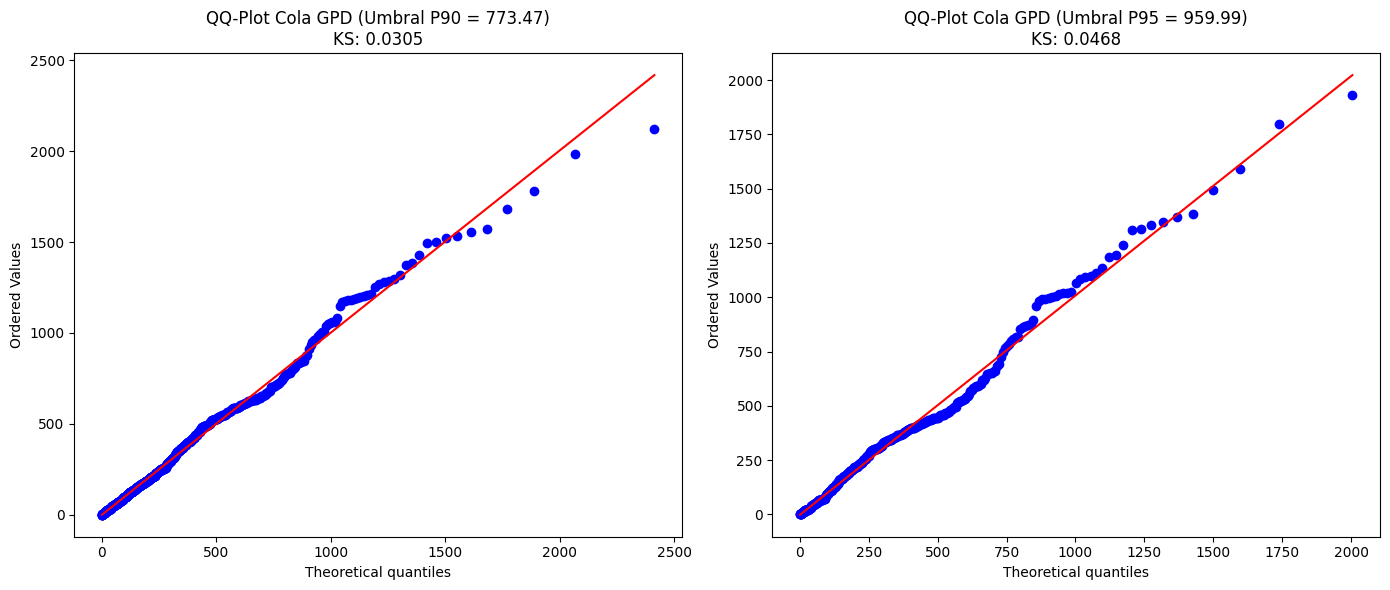

In [21]:
p90 = np.percentile(y_values, 90)
p95 = np.percentile(y_values, 95)

# 3. Calcular los excesos (Siniestro - Umbral)
exc_90 = y_values[y_values > p90] - p90
exc_95 = y_values[y_values > p95] - p95

# 4. Ajustar la GPD a los excesos
# En POT, la localización (floc) se fija en 0 porque ya hemos restado el umbral.
params_90 = genpareto.fit(exc_90, floc=0)
params_95 = genpareto.fit(exc_95, floc=0)

# 5. Calcular el Estadístico Kolmogorov-Smirnov (KS)
ks_90 = kstest(exc_90, 'genpareto', args=params_90)
ks_95 = kstest(exc_95, 'genpareto', args=params_95)

print(f"P90 | Umbral: {p90:.2f} | KS: {ks_90.statistic:.4f} | p-valor: {ks_90.pvalue:.4f}")
print(f"P95 | Umbral: {p95:.2f} | KS: {ks_95.statistic:.4f} | p-valor: {ks_95.pvalue:.4f}")

# 6. Dibujar los QQ-Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# QQ-Plot para P90
probplot(exc_90, dist=genpareto, sparams=(params_90[0], params_90[1], params_90[2]), plot=axes[0])
axes[0].set_title(f"QQ-Plot Cola GPD (Umbral P90 = {p90:.2f})\nKS: {ks_90.statistic:.4f}")

# QQ-Plot para P95
probplot(exc_95, dist=genpareto, sparams=(params_95[0], params_95[1], params_95[2]), plot=axes[1])
axes[1].set_title(f"QQ-Plot Cola GPD (Umbral P95 = {p95:.2f})\nKS: {ks_95.statistic:.4f}")

plt.tight_layout()

Decidimos fijar el umbral _u_ en el percentil 90 pues nos devuelve los menores valores para el estadístico de contraste del Test de Bondad de Ajuste de Kolgomorov-Smirnov.

### 1.3 MODELAR LA VARIABLE OBJETIVO

Podemos entender el riesgo de cola que acabamos de asumir como que, empíricamente, el 10% de las observaciones de siniestralidad superan el percentil 90% y siguen una Pareto Generalizada; el 90% restante tiene una severidad que sigue una Gamma. En consecuencia, no podemos usar un único modelo simple para estimar la Severidad Total, debemos construir un Modelo Empalmado o Compuesto:
1. **Clasificador**. Antes de modelar el coste de un asegurado debemos estimar la probabilidad de que su severidad sea normal o extrema. Para cada asegurado $i$ calcularemos $P_i(Cuerpo)$, la probabilidad de que su `Total Claim Amount` quede por debajo del umbral (percentil 90%), y $P_i(Cola)=1-P_i(Cuerpo)$.
2. **Estimador del Cuerpo**. Condicionado a que el asegurado tiene un coste normal, usamos un GLM Gamma para estimar su siniestralidad total. Este GLM se entrenará exclusivamente con datos de severidades en el cuerpo.
3. **Estimador de la Cola**. Condicionado a que el asegurado tiene una severidad extrema, predecimos su `Total Claim Amount` como el umbral más el exceso que determine la Pareto Generalizada (GPD).

Usando el Teorema de la Probabilidad Total, la predicción individual del `Total Claim Amount` para el asegurado $i$ es:

$$\hat{E}_i[Total\ Claim\ Amount]:=P_i(Cuerpo)\cdot E_i[Cuerpo] + P_i(Cola)\cdot \left(Umbral+E_i[Exceso\ de\ Cola]\right)$$

Y la prima técnica agregada de la cartera de $n$ asegurados se obtiene sumando las predicciones individuales:

$$\hat{S} = \sum_{i=1}^{n} \hat{E}_i[Total\ Claim\ Amount]$$

lo que hace al modelo directamente utilizable para tarificación y reservas.